# Code for the second figure of Section 5.13: Learning Initialization Distributions and Neonatal Locomotion in Ungulates

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torchvision.transforms import v2
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import random
import torch.autograd as autograd
import math
from matplotlib import pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using {device} device")
class ClassicNetwork(nn.Module):
    def __init__(self, layer_sizes,bias=True):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            *[z for l in layer_sizes
              for z in [nn.Linear(l[0], l[1],bias=bias), nn.ReLU()]][:-1]
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

# Set up signed Kaiming initialization.
def signed_kaiming_constant_(tensor, a=0, mode='fan_in', nonlinearity='relu', k=0.5, sparsity=0):
    fan = nn.init._calculate_correct_fan(tensor, mode)  # calculating correct fan, depends on shape and type of nn
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = (gain / math.sqrt(fan))
    # scale by (1/sqrt(k))
    if k != 0:
        std *= (1 / math.sqrt(k))
    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            mask = (torch.rand_like(tensor) > sparsity).float()  # Keeps (1 - sparsity)% weights
            tensor *= mask
        return tensor

# A function to retreive a subset of the top k% of the weights by their score.
# The gradient is estimated by the identity (i.e. it goes "straight-through").
# See the paper "What's Hidden in a Randomly Weighted Neural Network?" for
# more details (https://arxiv.org/abs/1911.13299)
# (this code adapted from https://github.com/iceychris/edge-popup)
class GetSubnet(autograd.Function):
    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Get the subnetwork by sorting the scores and using the top k%
        out = scores.clone()
        _, idx = scores.flatten().sort()
        j = int((1-k) * scores.numel())
        # flat_out and out access the same memory.
        flat_out = out.flatten()
        flat_out[idx[:j]] = 0
        flat_out[idx[j:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # send the gradient g straight-through on the backward pass.
        return grad, None

class LinearSubnet(nn.Linear):
    def __init__(self, in_features, out_features, init=signed_kaiming_constant_, k=0.5, extra_capacity=0, double=True, **kwargs):
        super().__init__(in_features, out_features, **kwargs)
        if double:
          multiplier=2
        else:
          multiplier=1
        self.scores = nn.Parameter(torch.randn(out_features,multiplier*in_features+extra_capacity))
        init(self.weight)
        self.weight.requires_grad_(False)
        self.scores.requires_grad_(True)
        if self.bias is not None:
          self.bias_scores = nn.Parameter(torch.randn(multiplier+extra_capacity,out_features))
          self.bias.requires_grad_(False)
          self.bias_scores.requires_grad_(True)
        self.mode= "mask"
        self.k=k
    def forward(self, x):
      if self.mode!= "static":
        mask = GetSubnet.apply(self.scores.abs(),self.k)
        weight = self.weight * mask[:, :self.weight.shape[-1]]
        if self.bias is not None:
          bias_mask = GetSubnet.apply(self.bias_scores.abs(),self.k)
          bias = self.bias * bias_mask[1,:self.bias.shape[-1]]
          return F.linear(x, weight, bias)
        return F.linear(x,weight)
      else:
        return F.linear(x,self.weight)

    def toggle_mode(self, mode):
        self.mode = mode
        if mode=='classic':
            self.weight.requires_grad_(True)
            self.scores.requires_grad_(False)
            if self.bias is not None:
              self.bias.requires_grad_(True)
              self.bias_scores.requires_grad_(False)
        if mode=='mask':
            self.weight.requires_grad_(False)
            self.scores.requires_grad_(True)
            if self.bias is not None:
              self.bias.requires_grad_(False)
              self.bias_scores.requires_grad_(True)
        if mode=='hybrid':
            self.weight.requires_grad_(True)
            self.scores.requires_grad_(True)
            if self.bias is not None:
              self.bias.requires_grad_(True)
              self.bias_scores.requires_grad_(True)
        if mode=='static':
            self.weight.requires_grad_(False)
            self.scores.requires_grad_(False)
            if self.bias is not None:
              self.bias.requires_grad_(False)
              self.bias_scores.requires_grad_(False)

class Network(nn.Module):
    def __init__(self, layer_sizes, init=signed_kaiming_constant_, bias=True, double=True, extra_capacity=0):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
                *[z for i,l in enumerate(layer_sizes)
                  for z in [LinearSubnet(l[0], l[1],bias=bias, double=double, extra_capacity=extra_capacity), nn.ReLU()]][:-1]
            )
    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)
    def toggle_mode(self, mode):
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.toggle_mode(mode)
    def set_ks(self,ks):
        i=0
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.k=ks[i]
                i+=1

Using cpu device


Init: fitness = 0.435036, sigma = 0.2000
Gen 00: parent_fit = 0.433781, best_child_fit = 0.433781, sigma = 0.2200, improved = True
Gen 01: parent_fit = 0.389980, best_child_fit = 0.389980, sigma = 0.2420, improved = True
Gen 02: parent_fit = 0.299082, best_child_fit = 0.299082, sigma = 0.2662, improved = True
Gen 03: parent_fit = 0.299082, best_child_fit = 0.534224, sigma = 0.2396, improved = False
Gen 04: parent_fit = 0.299082, best_child_fit = 0.402299, sigma = 0.2156, improved = False
Gen 05: parent_fit = 0.281663, best_child_fit = 0.281663, sigma = 0.2372, improved = True
Gen 06: parent_fit = 0.279261, best_child_fit = 0.279261, sigma = 0.2609, improved = True
Gen 07: parent_fit = 0.279261, best_child_fit = 0.395076, sigma = 0.2348, improved = False
Gen 08: parent_fit = 0.279261, best_child_fit = 0.427136, sigma = 0.2113, improved = False
Gen 09: parent_fit = 0.279261, best_child_fit = 0.279372, sigma = 0.1902, improved = False

Best found init distribution (ES):
  l0_mu0: 0.32415


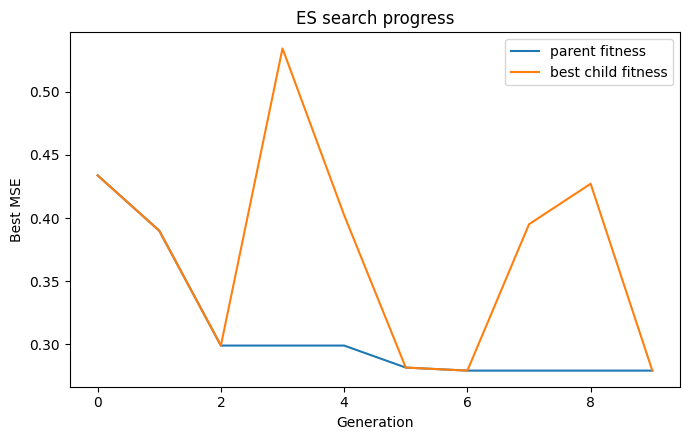

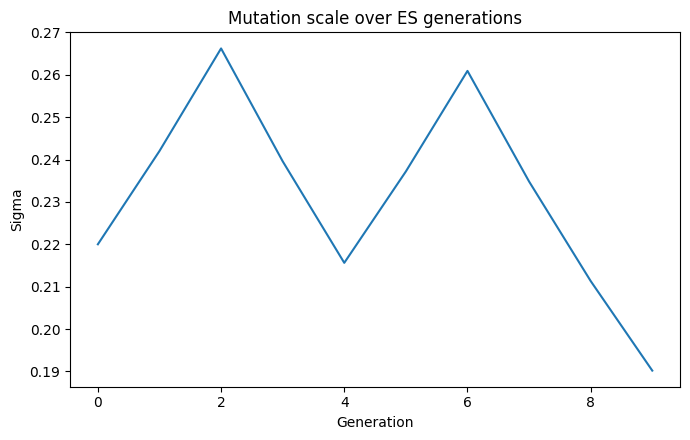

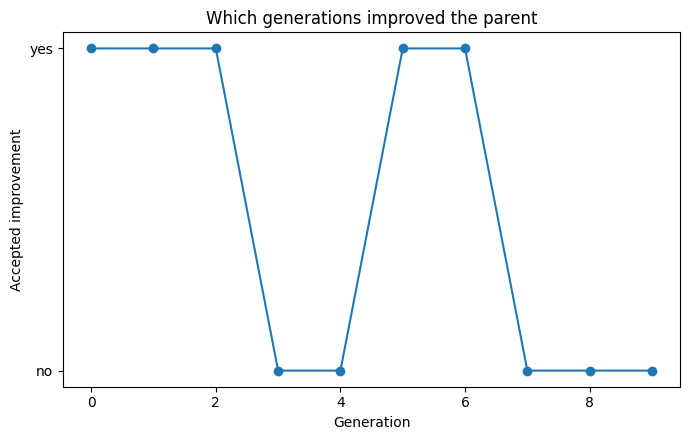

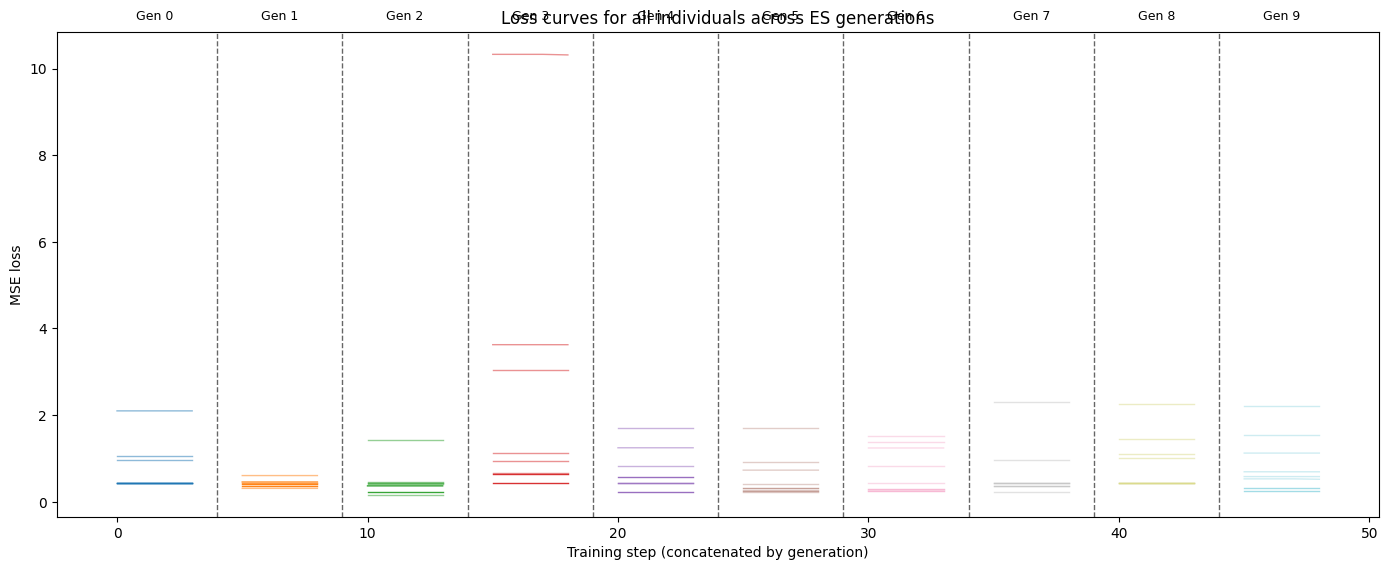

step 0: loss = 2.059866
step 1: loss = 2.059866
step 2: loss = 2.059866
step 3: loss = 2.059866
step 4: loss = 2.059866
step 5: loss = 2.059866
step 6: loss = 2.059866
step 7: loss = 2.059866
step 8: loss = 2.059866
step 9: loss = 2.059866
step 10: loss = 2.059866
step 11: loss = 2.059866
step 12: loss = 2.059866
step 13: loss = 2.059866
step 14: loss = 2.059866
step 15: loss = 2.059866
step 16: loss = 2.059866
step 17: loss = 2.025838
step 18: loss = 2.025838
step 19: loss = 2.025838
step 20: loss = 2.025838
step 21: loss = 2.025838
step 22: loss = 2.025838
step 23: loss = 2.025838
step 24: loss = 2.025838
step 25: loss = 2.025838
step 26: loss = 2.025838
step 27: loss = 2.025838
step 28: loss = 2.025838
step 29: loss = 2.025838
step 30: loss = 2.025838
step 31: loss = 2.025838
step 32: loss = 2.025838
step 33: loss = 2.025838
step 34: loss = 2.025838
step 35: loss = 2.025838
step 36: loss = 2.025838
step 37: loss = 2.025838
step 38: loss = 2.025838
step 39: loss = 2.025838
step 40: l

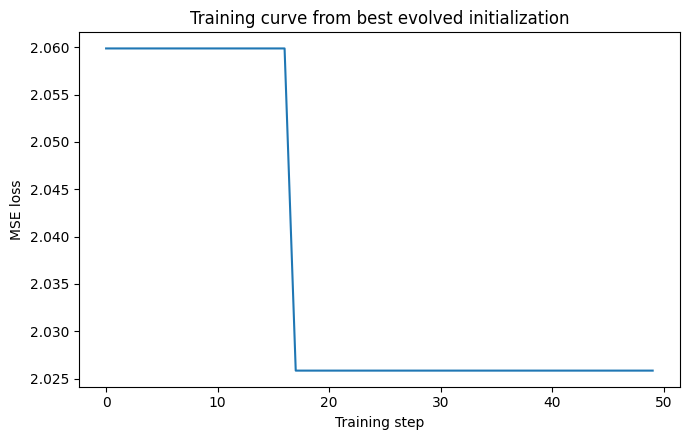

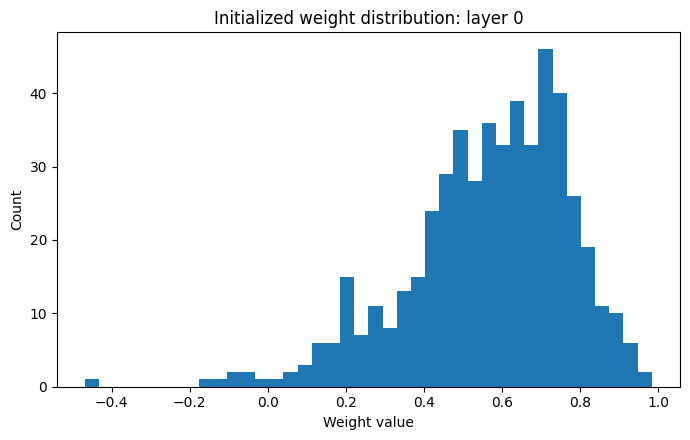

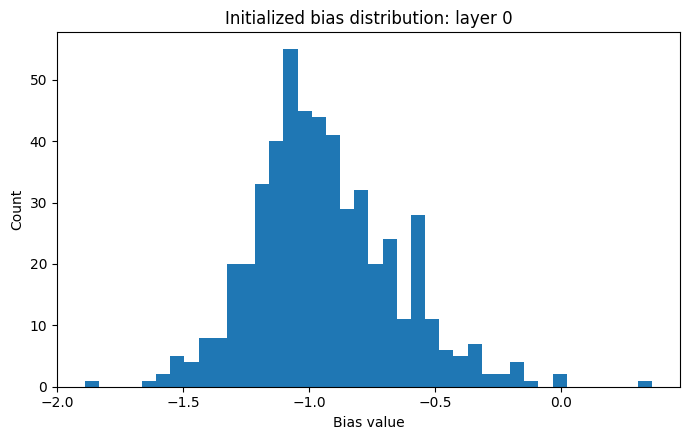

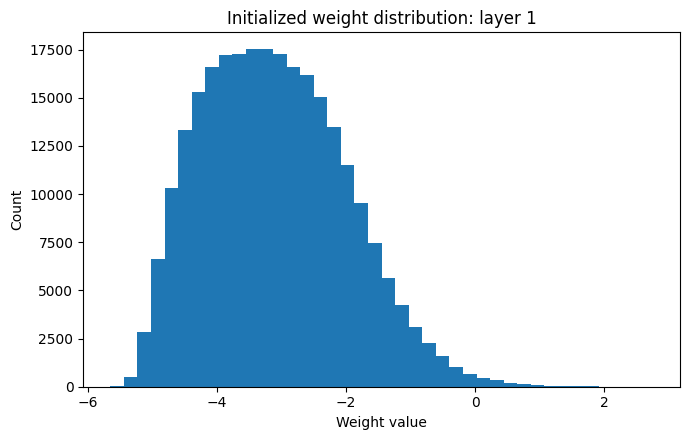

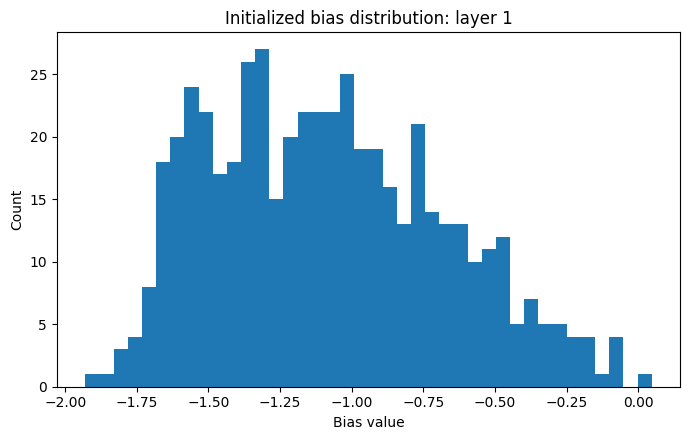

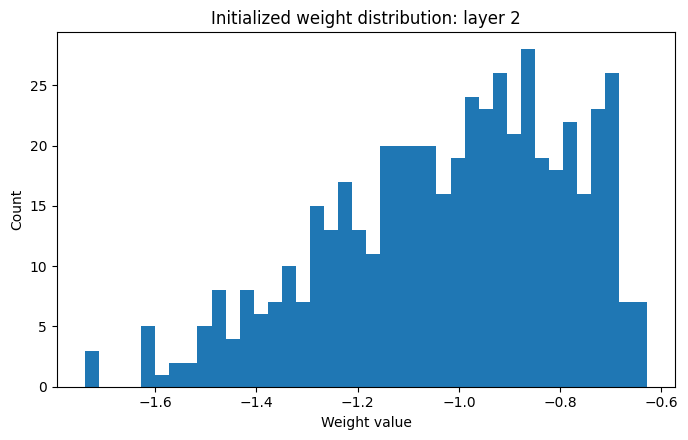

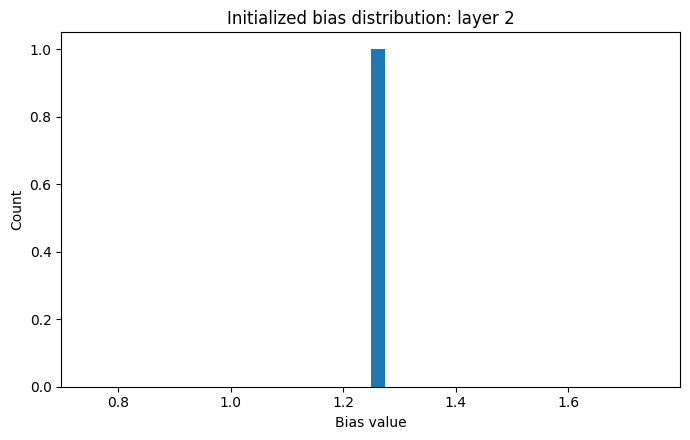

In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F


# ============================================================
# Initialization helpers
# ============================================================

def apply_genomic_init(model, individual, layer_sizes, device='cpu'):
    model.to(device)
    n_layers = len(layer_sizes)

    score_std_global      = individual["score_std"]
    bias_score_std_global = individual["bias_score_std"]

    layer_idx = 0
    with torch.no_grad():
        for layer in model.layers:
            if not isinstance(layer, LinearSubnet):
                continue

            out_features, in_features = layer.weight.shape

            # ----- weight index fields -----
            if out_features > 1:
                i_idx = torch.arange(out_features, device=device) / (out_features - 1)
            else:
                i_idx = torch.zeros(out_features, device=device)

            if in_features > 1:
                j_idx = torch.arange(in_features, device=device) / (in_features - 1)
            else:
                j_idx = torch.zeros(in_features, device=device)

            I, J = torch.meshgrid(i_idx, j_idx, indexing='ij')

            # ----- weight means / log-sigmas -----
            mu = (individual[f"l{layer_idx}_mu0"]
                  + individual[f"l{layer_idx}_mu_i"] * I
                  + individual[f"l{layer_idx}_mu_j"] * J)

            log_sigma = (individual[f"l{layer_idx}_ls0"]
                         + individual[f"l{layer_idx}_ls_i"] * I
                         + individual[f"l{layer_idx}_ls_j"] * J)

            W = mu + torch.exp(log_sigma) * torch.randn_like(mu)
            layer.weight.copy_(W)

            # ----- bias initialization -----
            if layer.bias is not None:
                bI = i_idx

                bmu = (individual[f"l{layer_idx}_bmu0"]
                       + individual[f"l{layer_idx}_bmu_i"] * bI)

                blog_sigma = (individual[f"l{layer_idx}_bls0"]
                              + individual[f"l{layer_idx}_bls_i"] * bI)

                b = bmu + torch.exp(blog_sigma) * torch.randn_like(bmu)
                layer.bias.copy_(b)

            layer_idx += 1

    model.toggle_mode("mask")
    return model


def init_network_from_individual(individual, layer_sizes, bias=False, device='cpu'):
    model = Network(layer_sizes, bias=bias)
    apply_genomic_init(model, individual, layer_sizes, device=device)
    return model


def make_random_individual(layer_sizes):
    n_layers = len(layer_sizes)
    ind = {}

    for l in range(n_layers):
        # Weight means
        ind[f"l{l}_mu0"]  = random.gauss(0.0, 1.0)
        ind[f"l{l}_mu_i"] = random.gauss(0.0, 1.0)
        ind[f"l{l}_mu_j"] = random.gauss(0.0, 1.0)

        # Weight log-sigmas
        ind[f"l{l}_ls0"]  = random.uniform(-2.0, 0.0)
        ind[f"l{l}_ls_i"] = random.uniform(-2.0, 0.0)
        ind[f"l{l}_ls_j"] = random.uniform(-2.0, 0.0)

        # Bias means
        ind[f"l{l}_bmu0"] = random.gauss(0.0, 1.0)
        ind[f"l{l}_bmu_i"] = random.gauss(0.0, 1.0)

        # Bias log-sigmas
        ind[f"l{l}_bls0"] = random.uniform(-2.0, 0.0)
        ind[f"l{l}_bls_i"] = random.uniform(-2.0, 0.0)

    ind["score_std"]      = 10 ** random.uniform(-2.0, 0.5)
    ind["bias_score_std"] = 10 ** random.uniform(-2.0, 0.5)

    return ind


# ============================================================
# Fitness evaluation
# ============================================================

def evaluate_individual(individual,
                        data_x,
                        data_y,
                        layer_sizes,
                        bias=False,
                        device='cpu',
                        steps=50,
                        trials=3,
                        return_history=False):
    """
    Mean best MSE across trials. Lower is better.

    If return_history=True, also returns a dict containing:
        trial_loss_histories: list of per-step loss curves, one per trial
        trial_best_losses:    best loss achieved in each trial
    """
    data_x = data_x.to(device)
    data_y = data_y.to(device)

    best_losses = []
    trial_loss_histories = []

    for _ in range(trials):
        model = init_network_from_individual(individual, layer_sizes, bias=bias, device=device)

        optimizer = torch.optim.Adam(
            [p for p in model.parameters() if p.requires_grad]
        )

        best_loss = float('inf')
        step_losses = []

        for t in range(steps):
            optimizer.zero_grad()
            preds = model(data_x)
            loss = F.mse_loss(preds, data_y)
            loss_val = loss.item()

            step_losses.append(loss_val)

            if loss_val < best_loss:
                best_loss = loss_val

            loss.backward()
            optimizer.step()

        best_losses.append(best_loss)
        trial_loss_histories.append(step_losses)

    mean_best_loss = sum(best_losses) / len(best_losses)

    if return_history:
        return mean_best_loss, {
            "trial_loss_histories": trial_loss_histories,
            "trial_best_losses": best_losses,
        }

    return mean_best_loss


# ============================================================
# Mutation
# ============================================================

def mutate_es(parent, layer_sizes, sigma):
    child = parent.copy()
    n_layers = len(layer_sizes)

    for l in range(n_layers):
        for key in [f"l{l}_mu0", f"l{l}_mu_i", f"l{l}_mu_j",
                    f"l{l}_ls0", f"l{l}_ls_i", f"l{l}_ls_j",
                    f"l{l}_bmu0", f"l{l}_bmu_i",
                    f"l{l}_bls0", f"l{l}_bls_i"]:
            child[key] = child[key] + random.gauss(0.0, sigma)

    # mutate global positive params in log space
    for key in ["score_std", "bias_score_std"]:
        log_val = math.log(child[key] + 1e-12)
        child[key] = math.exp(log_val + random.gauss(0.0, sigma))

    return child


# ============================================================
# ES search
# ============================================================

def run_es_search(
    data_x,
    data_y,
    layer_sizes=[[2, 2], [2, 2]],
    bias=False,
    device='cpu',
    generations=50,
    offspring_per_gen=8,
    init_sigma=0.2,
    steps=50,
    trials=3,
    sigma_inc=1.1,
    sigma_dec=0.9,
    record_all_histories=False,
):
    """
    Simple (1+λ)-ES for learning an initialization distribution.

    Returns:
        best_genome, best_fitness, history

    If record_all_histories=True, history also contains:
        history["offspring_trial_histories"][gen][child_idx][trial_idx][step]
        history["offspring_fitnesses"][gen][child_idx]
    """
    parent = make_random_individual(layer_sizes)
    sigma = init_sigma

    parent_fitness = evaluate_individual(
        parent, data_x, data_y,
        layer_sizes=layer_sizes,
        bias=bias,
        device=device,
        steps=steps,
        trials=trials
    )

    history = {
        "generation": [],
        "parent_fitness": [],
        "best_child_fitness": [],
        "sigma": [],
        "improved": [],
    }

    if record_all_histories:
        history["offspring_trial_histories"] = []
        history["offspring_fitnesses"] = []

    print(f"Init: fitness = {parent_fitness:.6f}, sigma = {sigma:.4f}")

    for gen in range(generations):
        offspring = []
        offspring_fitnesses = []
        offspring_histories_this_gen = []

        for _ in range(offspring_per_gen):
            child = mutate_es(parent, layer_sizes, sigma)

            if record_all_histories:
                fit, extra = evaluate_individual(
                    child, data_x, data_y,
                    layer_sizes=layer_sizes,
                    bias=bias,
                    device=device,
                    steps=steps,
                    trials=trials,
                    return_history=True
                )
                offspring_histories_this_gen.append(extra["trial_loss_histories"])
            else:
                fit = evaluate_individual(
                    child, data_x, data_y,
                    layer_sizes=layer_sizes,
                    bias=bias,
                    device=device,
                    steps=steps,
                    trials=trials
                )

            offspring.append(child)
            offspring_fitnesses.append(fit)

        best_idx = min(range(len(offspring_fitnesses)),
                       key=lambda i: offspring_fitnesses[i])
        best_child = offspring[best_idx]
        best_child_fitness = offspring_fitnesses[best_idx]

        if best_child_fitness < parent_fitness:
            parent = best_child
            parent_fitness = best_child_fitness
            sigma *= sigma_inc
            improved = True
        else:
            sigma *= sigma_dec
            improved = False

        history["generation"].append(gen)
        history["parent_fitness"].append(parent_fitness)
        history["best_child_fitness"].append(best_child_fitness)
        history["sigma"].append(sigma)
        history["improved"].append(int(improved))

        if record_all_histories:
            history["offspring_trial_histories"].append(offspring_histories_this_gen)
            history["offspring_fitnesses"].append(offspring_fitnesses)

        print(f"Gen {gen:02d}: parent_fit = {parent_fitness:.6f}, "
              f"best_child_fit = {best_child_fitness:.6f}, "
              f"sigma = {sigma:.4f}, improved = {improved}")

    print("\nBest found init distribution (ES):")
    for k, v in parent.items():
        print(f"  {k}: {v:.5f}")
    print(f"Best mean best-loss: {parent_fitness:.6f}")

    return parent, parent_fitness, history


# ============================================================
# Training / plotting helpers
# ============================================================

def train_best_model(model, data_x, data_y, steps=50, device='cpu'):
    model = model.to(device)
    data_x = data_x.to(device)
    data_y = data_y.to(device)

    optimizer = torch.optim.Adam(model.parameters())
    losses = []

    for t in range(steps):
        optimizer.zero_grad()
        preds = model(data_x)
        loss = F.mse_loss(preds, data_y)
        losses.append(loss.item())
        print(f"step {t}: loss = {loss.item():.6f}")
        loss.backward()
        optimizer.step()

    return losses


def plot_es_history(history):
    gens = np.array(history["generation"])
    parent_fit = np.array(history["parent_fitness"])
    child_fit = np.array(history["best_child_fitness"])
    sigma = np.array(history["sigma"])
    improved = np.array(history["improved"])

    plt.figure(figsize=(7, 4.5))
    plt.plot(gens, parent_fit, label="parent fitness")
    plt.plot(gens, child_fit, label="best child fitness")
    plt.xlabel("Generation")
    plt.ylabel("Best MSE")
    plt.title("ES search progress")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(gens, sigma)
    plt.xlabel("Generation")
    plt.ylabel("Sigma")
    plt.title("Mutation scale over ES generations")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(gens, improved, marker='o')
    plt.xlabel("Generation")
    plt.ylabel("Accepted improvement")
    plt.title("Which generations improved the parent")
    plt.yticks([0, 1], ["no", "yes"])
    plt.tight_layout()
    plt.show()


def plot_training_curve(losses):
    plt.figure(figsize=(7, 4.5))
    plt.plot(np.arange(len(losses)), losses)
    plt.xlabel("Training step")
    plt.ylabel("MSE loss")
    plt.title("Training curve from best evolved initialization")
    plt.tight_layout()
    plt.show()


def plot_weight_histograms(model):
    layer_num = 0
    for layer in model.layers:
        if not isinstance(layer, LinearSubnet):
            continue

        W = layer.weight.detach().cpu().numpy().ravel()
        plt.figure(figsize=(7, 4.5))
        plt.hist(W, bins=40)
        plt.xlabel("Weight value")
        plt.ylabel("Count")
        plt.title(f"Initialized weight distribution: layer {layer_num}")
        plt.tight_layout()
        plt.show()

        if layer.bias is not None:
            b = layer.bias.detach().cpu().numpy().ravel()
            plt.figure(figsize=(7, 4.5))
            plt.hist(b, bins=40)
            plt.xlabel("Bias value")
            plt.ylabel("Count")
            plt.title(f"Initialized bias distribution: layer {layer_num}")
            plt.tight_layout()
            plt.show()

        layer_num += 1


def plot_all_individual_loss_curves_by_generation(
    history,
    gap=2.0,
    alpha_nonbest=0.10,
    alpha_best=0.95,
    linewidth_nonbest=1.0,
    linewidth_best=2.0,
    logy=True,
    color_by_generation=True,
    cmap_name="tab20",
):
    """
    Plot every trial loss curve for every offspring in every generation.

    Each generation is placed to the right of the previous one, separated by a gap.
    Dashed separators and generation labels are drawn.
    The best child in each generation is highlighted.

    Requires history fields:
        history["offspring_trial_histories"][gen][child_idx][trial_idx][step]
        history["offspring_fitnesses"][gen][child_idx]
    """
    if "offspring_trial_histories" not in history:
        raise ValueError(
            "history does not contain offspring trial histories. "
            "Run ES with record_all_histories=True."
        )

    offspring_trial_histories = history["offspring_trial_histories"]
    offspring_fitnesses = history["offspring_fitnesses"]

    n_generations = len(offspring_trial_histories)
    if n_generations == 0:
        print("No generations to plot.")
        return

    # infer number of steps from first available trial curve
    steps = None
    for gen_data in offspring_trial_histories:
        for child_data in gen_data:
            for trial_curve in child_data:
                steps = len(trial_curve)
                break
            if steps is not None:
                break
        if steps is not None:
            break

    if steps is None:
        print("No trial histories found.")
        return

    cmap = plt.get_cmap(cmap_name, max(n_generations, 2))

    plt.figure(figsize=(max(12, 0.8 * n_generations + 6), 5.8))

    # x-axis blocks
    for gen_idx, (gen_histories, gen_fitnesses) in enumerate(zip(offspring_trial_histories, offspring_fitnesses)):
        x_start = gen_idx * (steps + gap)
        x = np.arange(steps) + x_start

        best_child_idx = int(np.argmin(gen_fitnesses))
        gen_color = cmap(gen_idx) if color_by_generation else None

        for child_idx, child_trials in enumerate(gen_histories):
            is_best = (child_idx == best_child_idx)

            for trial_curve in child_trials:
                y = np.array(trial_curve, dtype=float)

                plt.plot(
                    x,
                    y,
                    color=gen_color,
                    alpha=alpha_best if is_best else alpha_nonbest,
                    linewidth=linewidth_best if is_best else linewidth_nonbest,
                )

        # dashed separator between generations
        if gen_idx < n_generations - 1:
            sep_x = x_start + steps - 0.5 + gap / 2.0
            plt.axvline(sep_x, linestyle="--", linewidth=1.0, alpha=0.6, color="black")

        # generation label centered over block
        center_x = x_start + (steps - 1) / 2.0
        plt.text(
            center_x,
            1.02,
            f"Gen {gen_idx}",
            ha="center",
            va="bottom",
            transform=plt.gca().get_xaxis_transform(),
            fontsize=9
        )

    plt.xlabel("Training step (concatenated by generation)")
    plt.ylabel("MSE loss")
    plt.title("Loss curves for all individuals across ES generations")

    if logy:
        plt.yscale("log")

    plt.tight_layout()
    plt.show()


# ============================================================
# Example usage
# ============================================================

device = 'cuda' if torch.cuda.is_available() else 'cpu'
layer_sizes = [[1, 512], [512, 512], [512, 1]]
data_x = torch.randn(1000, 1)
data_y = torch.sin(data_x)

best_genome, best_fit, es_history = run_es_search(
    data_x, data_y,
    layer_sizes=layer_sizes,
    bias=True,
    device=device,
    generations=10,
    offspring_per_gen=4,
    steps=4,
    trials=2,
    record_all_histories=True,   # IMPORTANT
)

plot_es_history(es_history)

plot_all_individual_loss_curves_by_generation(
    es_history,
    gap=1,
    alpha_nonbest=0.5,
    alpha_best=0.95,
    linewidth_nonbest=1.0,
    linewidth_best=1.0,
    logy=False,
    color_by_generation=True,
    cmap_name="tab20",
)

model = init_network_from_individual(best_genome, layer_sizes, bias=True, device=device)
model.toggle_mode("mask")

final_losses = train_best_model(
    model,
    data_x,
    data_y,
    steps=50,
    device=device
)

plot_training_curve(final_losses)
plot_weight_histograms(model)

In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ============================================================
# Fixed score initialization utilities
# ============================================================

def make_fixed_score_tensors(layer_sizes, bias=False, device='cpu',
                             score_init_type='normal',
                             score_std=1.0,
                             bias_score_std=1.0,
                             seed=0):
    """
    Create one fixed set of score tensors to be reused for every individual
    across all generations.
    """
    g = torch.Generator(device='cpu')
    g.manual_seed(seed)

    fixed_scores = {}

    for layer_idx, (in_features, out_features) in enumerate(layer_sizes):
        if score_init_type == 'normal':
            scores = torch.randn(out_features, 2 * in_features, generator=g) * score_std
            if bias:
                bias_scores = torch.randn(2, out_features, generator=g) * bias_score_std
            else:
                bias_scores = None
        elif score_init_type == 'zeros':
            scores = torch.zeros(out_features, 2 * in_features)
            bias_scores = torch.zeros(2, out_features) if bias else None
        else:
            raise ValueError(f"Unknown score_init_type: {score_init_type}")

        fixed_scores[layer_idx] = {
            "scores": scores.to(device),
            "bias_scores": None if bias_scores is None else bias_scores.to(device)
        }

    return fixed_scores


# ============================================================
# Initialization helpers
# ============================================================

def apply_genomic_init(model, individual, layer_sizes, fixed_scores, device='cpu'):
    """
    Initialize model weights/biases from genome, while copying in fixed scores.
    """
    model.to(device)

    layer_idx = 0
    with torch.no_grad():
        for layer in model.layers:
            if not isinstance(layer, LinearSubnet):
                continue

            out_features, in_features = layer.weight.shape

            # ----- weight index fields -----
            if out_features > 1:
                i_idx = torch.arange(out_features, device=device) / (out_features - 1)
            else:
                i_idx = torch.zeros(out_features, device=device)

            if in_features > 1:
                j_idx = torch.arange(in_features, device=device) / (in_features - 1)
            else:
                j_idx = torch.zeros(in_features, device=device)

            I, J = torch.meshgrid(i_idx, j_idx, indexing='ij')

            # ----- weight means / log-sigmas -----
            mu = (
                individual[f"l{layer_idx}_mu0"]
                + individual[f"l{layer_idx}_mu_i"] * I
                + individual[f"l{layer_idx}_mu_j"] * J
            )

            log_sigma = (
                individual[f"l{layer_idx}_ls0"]
                + individual[f"l{layer_idx}_ls_i"] * I
                + individual[f"l{layer_idx}_ls_j"] * J
            )

            W = mu + torch.exp(log_sigma) * torch.randn_like(mu)
            layer.weight.copy_(W)

            # ----- fixed score initialization -----
            if hasattr(layer, "scores") and layer.scores is not None:
                layer.scores.copy_(fixed_scores[layer_idx]["scores"])

            # ----- bias initialization -----
            if layer.bias is not None:
                bI = i_idx

                bmu = (
                    individual[f"l{layer_idx}_bmu0"]
                    + individual[f"l{layer_idx}_bmu_i"] * bI
                )

                blog_sigma = (
                    individual[f"l{layer_idx}_bls0"]
                    + individual[f"l{layer_idx}_bls_i"] * bI
                )

                b = bmu + torch.exp(blog_sigma) * torch.randn_like(bmu)
                layer.bias.copy_(b)

                if hasattr(layer, "bias_scores") and layer.bias_scores is not None:
                    fixed_bias_scores = fixed_scores[layer_idx]["bias_scores"]
                    if fixed_bias_scores is None:
                        layer.bias_scores.zero_()
                    else:
                        layer.bias_scores.copy_(fixed_bias_scores)

            layer_idx += 1

    model.toggle_mode("mask")
    return model


def init_network_from_individual(individual, layer_sizes, fixed_scores, bias=False, device='cpu'):
    model = Network(layer_sizes, bias=bias)
    apply_genomic_init(model, individual, layer_sizes, fixed_scores=fixed_scores, device=device)
    return model


def init_random_baseline_network(layer_sizes, fixed_scores, bias=False, device='cpu'):
    """
    Baseline model using ordinary random Network init, but with the same fixed scores.
    """
    model = Network(layer_sizes, bias=bias).to(device)

    layer_idx = 0
    with torch.no_grad():
        for layer in model.layers:
            if not isinstance(layer, LinearSubnet):
                continue

            if hasattr(layer, "scores") and layer.scores is not None:
                layer.scores.copy_(fixed_scores[layer_idx]["scores"])

            if layer.bias is not None and hasattr(layer, "bias_scores") and layer.bias_scores is not None:
                fixed_bias_scores = fixed_scores[layer_idx]["bias_scores"]
                if fixed_bias_scores is None:
                    layer.bias_scores.zero_()
                else:
                    layer.bias_scores.copy_(fixed_bias_scores)

            layer_idx += 1

    model.toggle_mode("mask")
    return model


def make_random_individual(layer_sizes):
    """
    Genome for ES. No score_std genes here since scores are fixed globally.
    """
    n_layers = len(layer_sizes)
    ind = {}

    for l in range(n_layers):
        # Weight means
        ind[f"l{l}_mu0"] = random.gauss(0.0, 1.0)
        ind[f"l{l}_mu_i"] = random.gauss(0.0, 1.0)
        ind[f"l{l}_mu_j"] = random.gauss(0.0, 1.0)

        # Weight log-sigmas
        ind[f"l{l}_ls0"] = random.uniform(-2.0, 0.0)
        ind[f"l{l}_ls_i"] = random.uniform(-2.0, 0.0)
        ind[f"l{l}_ls_j"] = random.uniform(-2.0, 0.0)

        # Bias means
        ind[f"l{l}_bmu0"] = random.gauss(0.0, 1.0)
        ind[f"l{l}_bmu_i"] = random.gauss(0.0, 1.0)

        # Bias log-sigmas
        ind[f"l{l}_bls0"] = random.uniform(-2.0, 0.0)
        ind[f"l{l}_bls_i"] = random.uniform(-2.0, 0.0)

    ind["lr"] = 10 ** random.uniform(-4.0, -1.0)

    return ind


# ============================================================
# Evaluation
# ============================================================

def evaluate_model_on_dataloader(model, dataloader, device='cpu'):
    """
    Average cross-entropy loss and accuracy over a dataloader.
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = F.cross_entropy(logits, y, reduction='sum')
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == y).sum().item()
            total_examples += y.numel()

    if total_examples == 0:
        return float('inf'), 0.0

    avg_loss = total_loss / total_examples
    acc = total_correct / total_examples
    return avg_loss, acc


def evaluate_individual(individual,
                        train_dataloader,
                        test_dataloader,
                        layer_sizes,
                        fixed_scores,
                        bias=False,
                        device='cpu',
                        steps=50,
                        return_history=False):
    """
    Train briefly on train_dataloader, then use TEST loss as fitness.

    Lower fitness = better.
    """
    model = init_network_from_individual(
        individual,
        layer_sizes,
        fixed_scores=fixed_scores,
        bias=bias,
        device=device
    )

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=individual["lr"]
    )

    step_losses = []

    model.train()
    for t, (X, y) in enumerate(train_dataloader):
        if t >= steps:
            break

        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()

        step_losses.append(loss.item())

    test_loss, test_acc = evaluate_model_on_dataloader(model, test_dataloader, device=device)

    if return_history:
        return test_loss, {
            "train_curve": step_losses,
            "best_trial_curve": step_losses,  # kept for compatibility with plotting
            "fitness_test_loss": test_loss,
            "fitness_test_acc": test_acc,
        }

    return test_loss


# ============================================================
# Mutation
# ============================================================

def mutate_es(parent, layer_sizes, sigma):
    child = parent.copy()
    n_layers = len(layer_sizes)

    for l in range(n_layers):
        for key in [
            f"l{l}_mu0", f"l{l}_mu_i", f"l{l}_mu_j",
            f"l{l}_ls0", f"l{l}_ls_i", f"l{l}_ls_j",
            f"l{l}_bmu0", f"l{l}_bmu_i",
            f"l{l}_bls0", f"l{l}_bls_i"
        ]:
            child[key] = child[key] + random.gauss(0.0, sigma)

    log_val = math.log(child["lr"] + 1e-12)
    child["lr"] = math.exp(log_val + random.gauss(0.0, sigma))

    return child


# ============================================================
# ES search
# ============================================================

def run_es_search(
    train_dataloader,
    test_dataloader,
    layer_sizes=[[2, 2], [2, 2]],
    fixed_scores=None,
    bias=False,
    device='cpu',
    generations=50,
    offspring_per_gen=8,
    init_sigma=0.2,
    steps=50,
    sigma_inc=1.1,
    sigma_dec=0.9,
    record_all_histories=False,
):
    """
    Simple (1+λ)-ES using TEST loss as fitness.
    """
    if fixed_scores is None:
        raise ValueError("run_es_search requires fixed_scores.")

    parent = make_random_individual(layer_sizes)
    sigma = init_sigma

    if record_all_histories:
        parent_fitness, parent_extra = evaluate_individual(
            parent,
            train_dataloader,
            test_dataloader,
            layer_sizes=layer_sizes,
            fixed_scores=fixed_scores,
            bias=bias,
            device=device,
            steps=steps,
            return_history=True
        )
        parent_test_acc = parent_extra["fitness_test_acc"]
    else:
        parent_fitness = evaluate_individual(
            parent,
            train_dataloader,
            test_dataloader,
            layer_sizes=layer_sizes,
            fixed_scores=fixed_scores,
            bias=bias,
            device=device,
            steps=steps,
            return_history=False
        )
        parent_test_acc = None

    history = {
        "generation": [],
        "parent_fitness": [],
        "best_child_fitness": [],
        "sigma": [],
        "improved": [],
        "parent_test_acc": [],
        "best_child_test_acc": [],
    }

    if record_all_histories:
        history["offspring_trial_histories"] = []
        history["offspring_fitnesses"] = []
        history["offspring_test_accs"] = []

    init_msg = f"Init: test_loss = {parent_fitness:.6f}, sigma = {sigma:.4f}"
    if parent_test_acc is not None:
        init_msg += f", test_acc = {parent_test_acc:.4f}"
    print(init_msg)

    for gen in range(generations):
        offspring = []
        offspring_fitnesses = []
        offspring_test_accs = []
        offspring_histories_this_gen = []

        for _ in range(offspring_per_gen):
            child = mutate_es(parent, layer_sizes, sigma)

            if record_all_histories:
                fit, extra = evaluate_individual(
                    child,
                    train_dataloader,
                    test_dataloader,
                    layer_sizes=layer_sizes,
                    fixed_scores=fixed_scores,
                    bias=bias,
                    device=device,
                    steps=steps,
                    return_history=True
                )
                offspring_histories_this_gen.append(extra["train_curve"])
                offspring_test_accs.append(extra["fitness_test_acc"])
            else:
                fit = evaluate_individual(
                    child,
                    train_dataloader,
                    test_dataloader,
                    layer_sizes=layer_sizes,
                    fixed_scores=fixed_scores,
                    bias=bias,
                    device=device,
                    steps=steps,
                    return_history=False
                )
                offspring_test_accs.append(np.nan)

            offspring.append(child)
            offspring_fitnesses.append(fit)

        best_idx = min(range(len(offspring_fitnesses)), key=lambda i: offspring_fitnesses[i])
        best_child = offspring[best_idx]
        best_child_fitness = offspring_fitnesses[best_idx]
        best_child_test_acc = offspring_test_accs[best_idx]

        if best_child_fitness < parent_fitness:
            parent = best_child
            parent_fitness = best_child_fitness
            parent_test_acc = best_child_test_acc
            sigma *= sigma_inc
            improved = True
        else:
            sigma *= sigma_dec
            improved = False

        history["generation"].append(gen)
        history["parent_fitness"].append(parent_fitness)
        history["best_child_fitness"].append(best_child_fitness)
        history["sigma"].append(sigma)
        history["improved"].append(int(improved))
        history["parent_test_acc"].append(parent_test_acc if parent_test_acc is not None else np.nan)
        history["best_child_test_acc"].append(best_child_test_acc)

        if record_all_histories:
            history["offspring_trial_histories"].append(offspring_histories_this_gen)
            history["offspring_fitnesses"].append(offspring_fitnesses)
            history["offspring_test_accs"].append(offspring_test_accs)

        print(
            f"Gen {gen:02d}: "
            f"parent_test_loss = {parent_fitness:.6f}, "
            f"best_child_test_loss = {best_child_fitness:.6f}, "
            f"sigma = {sigma:.4f}, improved = {improved}, "
            f"best_child_test_acc = {best_child_test_acc:.4f}"
        )

    print("\nBest found init distribution (ES):")
    for k, v in parent.items():
        print(f"  {k}: {v:.5f}")
    print(f"Best test loss: {parent_fitness:.6f}")
    if parent_test_acc is not None:
        print(f"Best test accuracy: {parent_test_acc:.4f}")

    return parent, parent_fitness, history


# ============================================================
# Training / plotting helpers
# ============================================================

def train_best_model(best_individual,
                     train_dataloader,
                     test_dataloader,
                     layer_sizes,
                     fixed_scores,
                     bias=False,
                     steps=50,
                     device='cpu',
                     baseline_lr=None):
    """
    Train and compare:
      1. the best evolved initialization
      2. a fresh random baseline initialization
    """
    evolved_model = init_network_from_individual(
        best_individual,
        layer_sizes,
        fixed_scores=fixed_scores,
        bias=bias,
        device=device
    )

    baseline_model = init_random_baseline_network(
        layer_sizes,
        fixed_scores=fixed_scores,
        bias=bias,
        device=device
    )

    evolved_lr = best_individual["lr"]
    if baseline_lr is None:
        baseline_lr = evolved_lr

    evolved_optimizer = torch.optim.Adam(
        [p for p in evolved_model.parameters() if p.requires_grad],
        lr=evolved_lr
    )
    baseline_optimizer = torch.optim.Adam(
        [p for p in baseline_model.parameters() if p.requires_grad],
        lr=baseline_lr
    )

    evolved_losses = []
    baseline_losses = []

    evolved_model.train()
    baseline_model.train()

    for t, (X, y) in enumerate(train_dataloader):
        if t >= steps:
            break

        X, y = X.to(device), y.to(device)

        evolved_optimizer.zero_grad()
        evolved_logits = evolved_model(X)
        evolved_loss = F.cross_entropy(evolved_logits, y)
        evolved_loss.backward()
        evolved_optimizer.step()
        evolved_losses.append(evolved_loss.item())

        baseline_optimizer.zero_grad()
        baseline_logits = baseline_model(X)
        baseline_loss = F.cross_entropy(baseline_logits, y)
        baseline_loss.backward()
        baseline_optimizer.step()
        baseline_losses.append(baseline_loss.item())

        print(
            f"step {t}: "
            f"evolved train loss = {evolved_loss.item():.6f}, "
            f"baseline train loss = {baseline_loss.item():.6f}, "
            f"gap = {baseline_loss.item() - evolved_loss.item():.6f}"
        )

    evolved_test_loss, evolved_test_acc = evaluate_model_on_dataloader(
        evolved_model, test_dataloader, device=device
    )
    baseline_test_loss, baseline_test_acc = evaluate_model_on_dataloader(
        baseline_model, test_dataloader, device=device
    )

    results = {
        "evolved_model": evolved_model,
        "baseline_model": baseline_model,
        "evolved_losses": evolved_losses,
        "baseline_losses": baseline_losses,
        "evolved_final_loss": evolved_losses[-1] if len(evolved_losses) > 0 else None,
        "baseline_final_loss": baseline_losses[-1] if len(baseline_losses) > 0 else None,
        "evolved_best_loss": min(evolved_losses) if len(evolved_losses) > 0 else None,
        "baseline_best_loss": min(baseline_losses) if len(baseline_losses) > 0 else None,
        "evolved_test_loss": evolved_test_loss,
        "baseline_test_loss": baseline_test_loss,
        "evolved_test_acc": evolved_test_acc,
        "baseline_test_acc": baseline_test_acc,
        "test_loss_gap": baseline_test_loss - evolved_test_loss,
        "test_acc_gap": evolved_test_acc - baseline_test_acc,
    }

    return results


def plot_es_history(history):
    gens = np.array(history["generation"])
    parent_fit = np.array(history["parent_fitness"])
    child_fit = np.array(history["best_child_fitness"])
    sigma = np.array(history["sigma"])
    improved = np.array(history["improved"])
    parent_acc = np.array(history["parent_test_acc"])
    child_acc = np.array(history["best_child_test_acc"])

    plt.figure(figsize=(7, 4.5))
    plt.plot(gens, parent_fit, label="parent test loss")
    plt.plot(gens, child_fit, label="best child test loss")
    plt.xlabel("Generation")
    plt.ylabel("Test cross-entropy")
    plt.title("ES search progress")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(gens, sigma)
    plt.xlabel("Generation")
    plt.ylabel("Sigma")
    plt.title("Mutation scale over ES generations")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(gens, improved, marker='o')
    plt.xlabel("Generation")
    plt.ylabel("Accepted improvement")
    plt.title("Which generations improved the parent")
    plt.yticks([0, 1], ["no", "yes"])
    plt.tight_layout()
    plt.show()

    if not np.all(np.isnan(parent_acc)):
        plt.figure(figsize=(7, 4.5))
        plt.plot(gens, parent_acc, label="parent test acc")
        plt.plot(gens, child_acc, label="best child test acc")
        plt.xlabel("Generation")
        plt.ylabel("Test accuracy")
        plt.title("ES test accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_training_curve(results, use_logy=False):
    evolved_losses = results["evolved_losses"]
    baseline_losses = results["baseline_losses"]

    steps_arr = np.arange(len(evolved_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(steps_arr, evolved_losses, label="evolved initialization")
    plt.plot(steps_arr, baseline_losses, label="random baseline initialization")
    plt.xlabel("Training step")
    plt.ylabel("Train cross-entropy loss")
    plt.title("Training curves: evolved vs random baseline")
    if use_logy:
        plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if len(evolved_losses) == len(baseline_losses) and len(evolved_losses) > 0:
        gap = np.array(baseline_losses) - np.array(evolved_losses)

        plt.figure(figsize=(8, 4.5))
        plt.plot(steps_arr, gap)
        plt.axhline(0.0, linestyle='--', alpha=0.4)
        plt.xlabel("Training step")
        plt.ylabel("Baseline train loss - evolved train loss")
        plt.title("Training-loss gap (positive means evolved is better)")
        plt.tight_layout()
        plt.show()

    print(f"Evolved TEST loss:      {results['evolved_test_loss']:.6f}")
    print(f"Baseline TEST loss:     {results['baseline_test_loss']:.6f}")
    print(f"TEST loss gap:          {results['test_loss_gap']:.6f}")
    print(f"Evolved TEST accuracy:  {results['evolved_test_acc']:.4f}")
    print(f"Baseline TEST accuracy: {results['baseline_test_acc']:.4f}")
    print(f"TEST accuracy gap:      {results['test_acc_gap']:.4f}")


def plot_weight_histograms_overlay(
    evolved_model,
    baseline_model,
    bins=40,
    alpha=0.5,
    same_xlim=True,
    same_ylim=False,
):
    """
    Overlay histograms of evolved vs baseline weights for all layers.
    """
    evolved_layers = [l for l in evolved_model.layers if isinstance(l, LinearSubnet)]
    baseline_layers = [l for l in baseline_model.layers if isinstance(l, LinearSubnet)]

    assert len(evolved_layers) == len(baseline_layers)

    n_layers = len(evolved_layers)
    ncols = int(np.ceil(np.sqrt(n_layers)))
    nrows = int(np.ceil(n_layers / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.array(axes).reshape(-1)

    global_min = float('inf')
    global_max = float('-inf')

    if same_xlim:
        for l1, l2 in zip(evolved_layers, baseline_layers):
            w1 = l1.weight.detach().cpu().numpy().ravel()
            w2 = l2.weight.detach().cpu().numpy().ravel()
            global_min = min(global_min, w1.min(), w2.min())
            global_max = max(global_max, w1.max(), w2.max())

    global_ymax = 0
    hist_data = []

    for l1, l2 in zip(evolved_layers, baseline_layers):
        w1 = l1.weight.detach().cpu().numpy().ravel()
        w2 = l2.weight.detach().cpu().numpy().ravel()

        if same_xlim:
            bins_edges = np.linspace(global_min, global_max, bins + 1)
        else:
            combined = np.concatenate([w1, w2])
            bins_edges = np.histogram_bin_edges(combined, bins=bins)

        h1, _ = np.histogram(w1, bins=bins_edges, density=True)
        h2, _ = np.histogram(w2, bins=bins_edges, density=True)
        global_ymax = max(global_ymax, h1.max(), h2.max())

        hist_data.append((w1, w2, bins_edges))

    for idx, ax in enumerate(axes):
        if idx >= n_layers:
            ax.axis("off")
            continue

        w1, w2, bins_edges = hist_data[idx]

        ax.hist(w2, bins=bins_edges, alpha=alpha, density=True, label="baseline", color='tab:orange')
        ax.hist(w1, bins=bins_edges, alpha=alpha, density=True, label="evolved", color='tab:blue')

        ax.set_title(f"Layer {idx}")
        ax.set_xlabel("Weight value")
        ax.set_ylabel("Density")

        if same_xlim:
            ax.set_xlim(global_min, global_max)
        if same_ylim:
            ax.set_ylim(0, global_ymax)

        if idx == 0:
            ax.legend()

    plt.suptitle("Weight Distributions: Evolved vs Baseline (Overlayed)", fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_all_individual_loss_curves_by_generation(
    history,
    gap=2.0,
    alpha_nonbest=0.10,
    alpha_best=0.95,
    linewidth_nonbest=1.0,
    linewidth_best=2.0,
    logy=True,
    color_by_generation=True,
    cmap_name="tab20",
):
    """
    Plot every TRAINING curve for every offspring in every generation.

    Best child is determined by TEST loss fitness, but what is plotted here
    is the short training trajectory.
    """
    if "offspring_trial_histories" not in history:
        raise ValueError(
            "history does not contain offspring trial histories. "
            "Run ES with record_all_histories=True."
        )

    offspring_trial_histories = history["offspring_trial_histories"]
    offspring_fitnesses = history["offspring_fitnesses"]

    n_generations = len(offspring_trial_histories)
    if n_generations == 0:
        print("No generations to plot.")
        return

    steps = None
    for gen_data in offspring_trial_histories:
        for child_curve in gen_data:
            steps = len(child_curve)
            break
        if steps is not None:
            break

    if steps is None:
        print("No histories found.")
        return

    cmap = plt.get_cmap(cmap_name, max(n_generations, 2))

    plt.figure(figsize=(max(12, 0.8 * n_generations + 6), 5.8))

    for gen_idx, (gen_histories, gen_fitnesses) in enumerate(zip(offspring_trial_histories, offspring_fitnesses)):
        x_start = gen_idx * (steps + gap)
        x = np.arange(steps) + x_start

        best_child_idx = int(np.argmin(gen_fitnesses))
        gen_color = cmap(gen_idx) if color_by_generation else None

        for child_idx, trial_curve in enumerate(gen_histories):
            is_best = (child_idx == best_child_idx)
            y = np.array(trial_curve, dtype=float)

            plt.plot(
                x,
                y,
                color=gen_color,
                alpha=alpha_best if is_best else alpha_nonbest,
                linewidth=linewidth_best if is_best else linewidth_nonbest,
            )

        if gen_idx < n_generations - 1:
            sep_x = x_start + steps - 0.5 + gap / 2.0
            plt.axvline(sep_x, linestyle="--", linewidth=1.0, alpha=0.6, color="black")

        center_x = x_start + (steps - 1) / 2.0
        plt.text(
            center_x,
            1.02,
            f"Gen {gen_idx}",
            ha="center",
            va="bottom",
            transform=plt.gca().get_xaxis_transform(),
            fontsize=9
        )

    plt.xlabel("Training step (concatenated by generation)")
    plt.ylabel("Train cross-entropy loss")
    plt.title("Training curves for all individuals across ES generations")

    if logy:
        plt.yscale("log")

    plt.tight_layout()
    plt.show()


# ============================================================
# Example usage on digits
# ============================================================

device = 'cuda' if torch.cuda.is_available() else 'cpu'
layer_sizes = [[64, 128], [128, 10]]

from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X = digits.data.astype(np.float32) / 16.0
y = digits.target.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

batch_size = 32
train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

fixed_scores = make_fixed_score_tensors(
    layer_sizes=layer_sizes,
    bias=True,
    device=device,
    score_init_type='normal',   # or 'zeros'
    score_std=1.0,
    bias_score_std=1.0,
    seed=0
)

best_genome, best_fit, es_history = run_es_search(
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    layer_sizes=layer_sizes,
    fixed_scores=fixed_scores,
    bias=True,
    device=device,
    generations=100,
    offspring_per_gen=20,
    init_sigma=0.2,
    steps=20,
    sigma_inc=1.1,
    sigma_dec=0.9,
    record_all_histories=True,
)

plot_es_history(es_history)

plot_all_individual_loss_curves_by_generation(
    es_history,
    gap=1,
    alpha_nonbest=0.25,
    alpha_best=0.95,
    linewidth_nonbest=1.0,
    linewidth_best=2.0,
    logy=False,
    color_by_generation=True,
    cmap_name="tab20",
)

comparison_results = train_best_model(
    best_individual=best_genome,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    layer_sizes=layer_sizes,
    fixed_scores=fixed_scores,
    bias=True,
    steps=50,
    device=device
)

plot_training_curve(comparison_results, use_logy=True)

plot_weight_histograms_overlay(
    evolved_model=comparison_results["evolved_model"],
    baseline_model=comparison_results["baseline_model"],
    bins=50,
    alpha=0.5,
    same_xlim=True,
    same_ylim=False
)

Init: test_loss = 4.621802, sigma = 0.2000, test_acc = 0.1400
Gen 00: parent_test_loss = 2.325141, best_child_test_loss = 2.325141, sigma = 0.2200, improved = True, best_child_test_acc = 0.1000
Gen 01: parent_test_loss = 2.325141, best_child_test_loss = 2.326569, sigma = 0.1980, improved = False, best_child_test_acc = 0.1778
Gen 02: parent_test_loss = 2.268023, best_child_test_loss = 2.268023, sigma = 0.2178, improved = True, best_child_test_acc = 0.1844
Gen 03: parent_test_loss = 2.268023, best_child_test_loss = 2.356077, sigma = 0.1960, improved = False, best_child_test_acc = 0.1000
Gen 04: parent_test_loss = 2.268023, best_child_test_loss = 2.320019, sigma = 0.1764, improved = False, best_child_test_acc = 0.1000
Gen 05: parent_test_loss = 2.268023, best_child_test_loss = 2.299659, sigma = 0.1588, improved = False, best_child_test_acc = 0.1756
Gen 06: parent_test_loss = 2.268023, best_child_test_loss = 2.305268, sigma = 0.1429, improved = False, best_child_test_acc = 0.1067
Gen 07: p